In [1]:
#!/usr/bin/env python

In [2]:
# # 🚢 Titanic — LightGBM + XGBoost Ensemble
# 
# **Author:** Dean Wang (deanbatur)  
# **Competition:** Titanic - Machine Learning from Disaster  
# **Task:** Binary Classification — Predict survival  
# **Metric:** Accuracy  
# 
# Quick, clean approach: feature engineering + LightGBM/XGBoost ensemble with 3-fold StratifiedKFold CV.

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import xgboost as xgb

plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries loaded ✅")

Libraries loaded ✅


In [4]:
# Robust path detection
data_dir = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        filepath = os.path.join(dirname, filename)
        print(filepath)
        if 'train.csv' in filename and data_dir is None:
            data_dir = dirname

train = pd.read_csv(os.path.join(data_dir, 'train.csv'))
test = pd.read_csv(os.path.join(data_dir, 'test.csv'))

print(f"\nTrain: {train.shape}, Test: {test.shape}")

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv

Train: (891, 12), Test: (418, 11)


In [5]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
print(f"Survival rate: {train['Survived'].mean():.3f} ({train['Survived'].mean()*100:.1f}%)\n")
print("Missing values:")
print(train.isnull().sum()[train.isnull().sum() > 0])

Survival rate: 0.384 (38.4%)

Missing values:
Age         177
Cabin       687
Embarked      2
dtype: int64


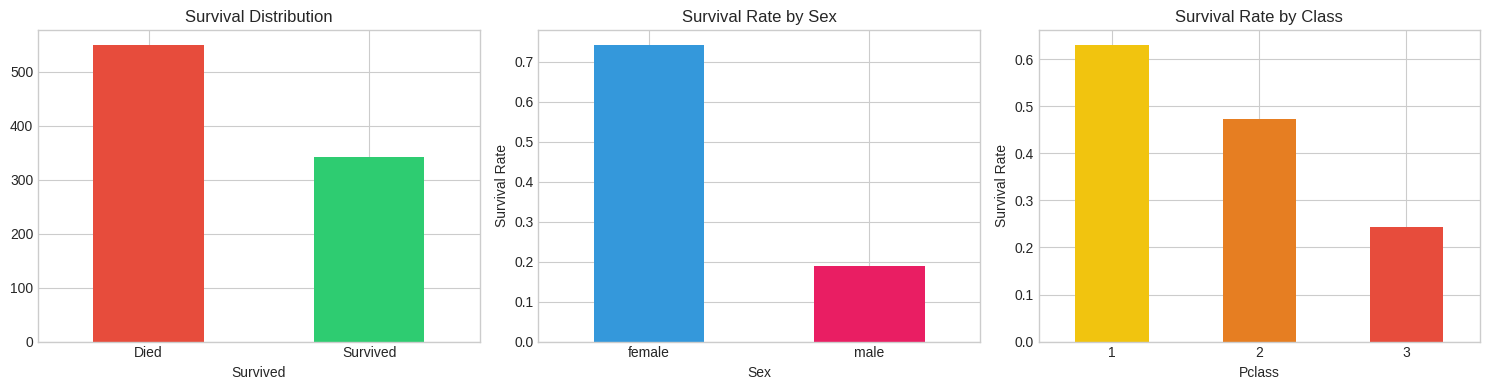

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

train['Survived'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Survival Distribution')
axes[0].set_xticklabels(['Died', 'Survived'], rotation=0)

train.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[1], color=['#3498db', '#e91e63'])
axes[1].set_title('Survival Rate by Sex')
axes[1].set_ylabel('Survival Rate')
axes[1].tick_params(axis='x', rotation=0)

train.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[2], color=['#f1c40f', '#e67e22', '#e74c3c'])
axes[2].set_title('Survival Rate by Class')
axes[2].set_ylabel('Survival Rate')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [8]:
def engineer_features(df):
    df = df.copy()
    
    # Title extraction
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    title_map = {
        'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
        'Dr': 'Rare', 'Rev': 'Rare', 'Col': 'Rare', 'Major': 'Rare',
        'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs', 'Don': 'Rare',
        'Dona': 'Rare', 'Lady': 'Rare', 'Countess': 'Rare', 'Sir': 'Rare',
        'Jonkheer': 'Rare', 'Capt': 'Rare'
    }
    df['Title'] = df['Title'].map(title_map).fillna('Rare')
    
    # Family features
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    df['FamilyBucket'] = pd.cut(df['FamilySize'], bins=[0, 1, 3, 5, 20], labels=[0, 1, 2, 3]).astype(int)
    
    # Age — fill missing with median by Title
    for title in df['Title'].unique():
        mask = (df['Title'] == title) & (df['Age'].isnull())
        df.loc[mask, 'Age'] = df[df['Title'] == title]['Age'].median()
    df['Age'] = df['Age'].fillna(df['Age'].median())
    
    # Age bins
    df['AgeBin'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], labels=[0, 1, 2, 3, 4]).astype(int)
    df['IsChild'] = (df['Age'] < 12).astype(int)
    
    # Fare — fill missing with median
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    df['FareBin'] = pd.qcut(df['Fare'], q=4, labels=[0, 1, 2, 3], duplicates='drop').astype(int)
    df['LogFare'] = np.log1p(df['Fare'])
    
    # Cabin
    df['HasCabin'] = df['Cabin'].notna().astype(int)
    df['CabinDeck'] = df['Cabin'].str[0].fillna('Unknown')
    
    # Embarked
    df['Embarked'] = df['Embarked'].fillna('S')
    
    # Interactions
    df['Sex_Pclass'] = df['Sex'] + '_' + df['Pclass'].astype(str)
    df['Age_x_Pclass'] = df['Age'] * df['Pclass']
    df['Fare_per_person'] = df['Fare'] / df['FamilySize']
    
    # Encode categoricals
    for col in ['Sex', 'Title', 'Embarked', 'CabinDeck', 'Sex_Pclass']:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
    
    # Drop unused columns
    drop_cols = ['Name', 'Ticket', 'Cabin', 'PassengerId']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')
    
    return df

train_fe = engineer_features(train)
test_fe = engineer_features(test)

# Align columns
features = [c for c in train_fe.columns if c != 'Survived']
for col in features:
    if col not in test_fe.columns:
        test_fe[col] = 0

print(f"Features: {len(features)}")
print(features)

Features: 20
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'FamilyBucket', 'AgeBin', 'IsChild', 'FareBin', 'LogFare', 'HasCabin', 'CabinDeck', 'Sex_Pclass', 'Age_x_Pclass', 'Fare_per_person']


In [9]:
X = train_fe[features].values
y = train_fe['Survived'].values
X_test = test_fe[features].values

N_FOLDS = 3
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

lgb_oof = np.zeros(len(X))
xgb_oof = np.zeros(len(X))
lgb_test_preds = np.zeros(len(X_test))
xgb_test_preds = np.zeros(len(X_test))

n_pos = y.sum()
n_neg = len(y) - n_pos
scale_pos = n_neg / n_pos

print(f"Train size: {len(X)}, Positive: {int(n_pos)}, Negative: {int(n_neg)}")
print(f"scale_pos_weight: {scale_pos:.2f}")
print(f"\nStarting {N_FOLDS}-Fold CV...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"--- FOLD {fold + 1} ---")
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    
    # LightGBM
    lgb_model = lgb.LGBMClassifier(
        objective='binary', metric='auc', verbosity=-1,
        n_estimators=1000, learning_rate=0.05,
        num_leaves=31, max_depth=6, min_child_samples=20,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        class_weight='balanced', random_state=42 + fold, n_jobs=-1,
    )
    lgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(200)]
    )
    lgb_val_pred = lgb_model.predict_proba(X_val)[:, 1]
    lgb_oof[val_idx] = lgb_val_pred
    lgb_test_preds += lgb_model.predict_proba(X_test)[:, 1] / N_FOLDS
    print(f"  LGB AUC: {roc_auc_score(y_val, lgb_val_pred):.4f}")
    
    # XGBoost
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic', eval_metric='auc',
        n_estimators=1000, learning_rate=0.05,
        max_depth=6, min_child_weight=20,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        scale_pos_weight=scale_pos, random_state=42 + fold, n_jobs=-1,
        tree_method='hist', verbosity=0,
    )
    xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=0)
    xgb_val_pred = xgb_model.predict_proba(X_val)[:, 1]
    xgb_oof[val_idx] = xgb_val_pred
    xgb_test_preds += xgb_model.predict_proba(X_test)[:, 1] / N_FOLDS
    print(f"  XGB AUC: {roc_auc_score(y_val, xgb_val_pred):.4f}")

Train size: 891, Positive: 342, Negative: 549
scale_pos_weight: 1.61

Starting 3-Fold CV...

--- FOLD 1 ---
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[82]	valid_0's auc: 0.892652
  LGB AUC: 0.8927
  XGB AUC: 0.8987
--- FOLD 2 ---
Training until validation scores don't improve for 50 rounds
[200]	valid_0's auc: 0.868637
Early stopping, best iteration is:
[179]	valid_0's auc: 0.870123
  LGB AUC: 0.8701
  XGB AUC: 0.8608
--- FOLD 3 ---
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[24]	valid_0's auc: 0.877265
  LGB AUC: 0.8773
  XGB AUC: 0.8644


In [10]:
# Results
ens_oof = 0.6 * lgb_oof + 0.4 * xgb_oof
print("\n" + "=" * 50)
print("CV RESULTS")
print("=" * 50)
print(f"LGB OOF AUC:      {roc_auc_score(y, lgb_oof):.4f}")
print(f"XGB OOF AUC:      {roc_auc_score(y, xgb_oof):.4f}")
print(f"Ensemble OOF AUC: {roc_auc_score(y, ens_oof):.4f}")
print(f"\nLGB Accuracy:      {accuracy_score(y, (lgb_oof > 0.5).astype(int)):.4f}")
print(f"XGB Accuracy:      {accuracy_score(y, (xgb_oof > 0.5).astype(int)):.4f}")
print(f"Ensemble Accuracy: {accuracy_score(y, (ens_oof > 0.5).astype(int)):.4f}")


CV RESULTS
LGB OOF AUC:      0.8702
XGB OOF AUC:      0.8739
Ensemble OOF AUC: 0.8775

LGB Accuracy:      0.8182
XGB Accuracy:      0.8148
Ensemble Accuracy: 0.8272


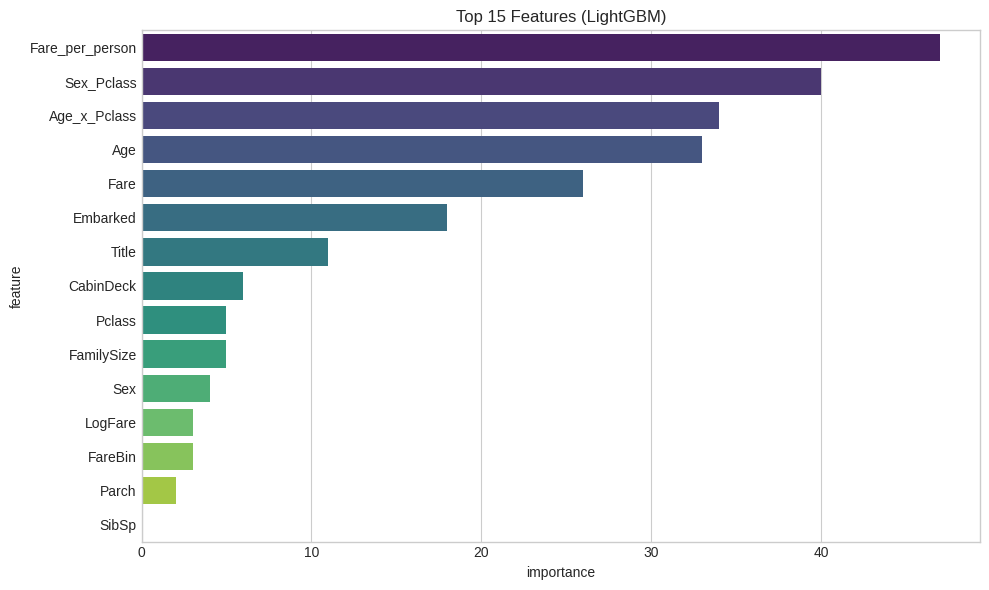

In [11]:
feat_imp = pd.DataFrame({
    'feature': features,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp.head(15), x='importance', y='feature', palette='viridis')
plt.title('Top 15 Features (LightGBM)')
plt.tight_layout()
plt.show()

In [12]:
final_preds = (0.6 * lgb_test_preds + 0.4 * xgb_test_preds)
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': (final_preds > 0.5).astype(int)
})

submission.to_csv('submission.csv', index=False)
print(f"Submission shape: {submission.shape}")
print(f"Predicted survival rate: {submission['Survived'].mean():.3f}")
print(submission.head(10))
print("\n✅ submission.csv saved — ready to submit!")

Submission shape: (418, 2)
Predicted survival rate: 0.395
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0

✅ submission.csv saved — ready to submit!
